# 04 · Live Inference — Validation & Tuning

Notebook 03 scored ~0.985 AUC on held-out ADFA-LD. That is a *lab* number:
same dataset, same ABI, whole traces at once.

Live is different in three ways, and each one has to be handled:

| Lab | Live |
|---|---|
| i686 syscall numbers | x86-64 from eBPF |
| complete trace | 100-syscall sliding window |
| offline scoring | per-process, continuous |

This notebook validates each, and derives the two constants
`src/dashboard.py` runs on: **threshold 0.9** and **50-syscall minimum**.

In [1]:
# ── Project paths (edit ADFA_ROOT if your dataset lives elsewhere) ────────────
import os, sys, glob, json, warnings
warnings.filterwarnings("ignore")

PROJECT   = "/home/sudipto-roy-s-hawon/Downloads/Project"
ADFA_ROOT = "/home/sudipto-roy-s-hawon/Downloads/ADFA-LD"
MODEL_DIR = os.path.join(PROJECT, "ml", "saved_model")
os.makedirs(MODEL_DIR, exist_ok=True)

# make `import live_predictor` work from inside ml/
sys.path.insert(0, os.path.join(PROJECT, "ml"))

assert os.path.isdir(ADFA_ROOT), f"ADFA-LD not found at {ADFA_ROOT}"
print("Project  :", PROJECT)
print("Dataset  :", ADFA_ROOT)
print("Models   :", MODEL_DIR)

Project  : /home/sudipto-roy-s-hawon/Downloads/Project
Dataset  : /home/sudipto-roy-s-hawon/Downloads/ADFA-LD
Models   : /home/sudipto-roy-s-hawon/Downloads/Project/ml/saved_model


## 1 · Load the live predictor

The same class `dashboard.py` imports.

In [2]:
from live_predictor import LivePredictor

p = LivePredictor()
assert p.ready, "model missing — run 03_lstm_train.ipynb first"

print()
print(f"  device               : {'cuda' if __import__('torch').cuda.is_available() else 'cpu'}")
print(f"  alert threshold      : {p.ALERT_SCORE}")
print(f"  full window          : {p.WINDOW_SIZE} syscalls")
print(f"  min to display       : {p.MIN_DISPLAY_SYSCALLS} syscalls")
print(f"  ABI translations     : {len(p.syscall_map)}")

[ML] LSTM loaded on cuda | AUC=0.9834
[ML] Syscall ABI map loaded: 376 x86_64 → i686 translations
[ML] LivePredictor initialized ✓

  device               : cuda
  alert threshold      : 0.9
  full window          : 100 syscalls
  min to display       : 50 syscalls
  ABI translations     : 376


## 2 · ABI translation

The table built in notebook 01, now in the live path.

In [3]:
print(f"{'sent by eBPF':>14}   {'model receives':>14}")
print("-" * 34)
for name, nr in [("read",0), ("write",1), ("open",2), ("close",3),
                 ("mmap",9), ("execve",59), ("openat",257)]:
    print(f"{name+' ('+str(nr)+')':>14}   ->  {p.translate(nr):>10}")

assert p.translate(257) == 5 and p.translate(0) == 3
print("\nopenat(257)->open(5), read(0)->read(3)  — correct")

  sent by eBPF   model receives
----------------------------------
      read (0)   ->           3
     write (1)   ->           4
      open (2)   ->           5
     close (3)   ->           6
      mmap (9)   ->         192
   execve (59)   ->          11
  openat (257)   ->           5

openat(257)->open(5), read(0)->read(3)  — correct


## 3 · Replay ADFA-LD as if it came from eBPF

The honest test. We invert the map to turn i686 traces back into the x86-64
numbers our sensor would emit, then feed them through the live path — the exact
journey a real syscall takes.

In [4]:
import numpy as np

# i686 -> x86-64, so we can simulate what the sensor sends
inv = {}
for x64, i686 in p.syscall_map.items():
    inv.setdefault(i686, x64)

def read_trace(f):
    return [int(x) for x in open(f).read().split() if x.isdigit()]

def replay(path, n_syscalls=100, pid_base=50000, limit=80):
    """Feed traces through add_syscall() as x86-64; collect final scores."""
    scores = []
    for i, f in enumerate(sorted(glob.glob(path))[:limit]):
        t = read_trace(f)
        if len(t) < n_syscalls:
            continue
        pid = pid_base + i
        p.buffers.pop(pid, None); p.scores.pop(pid, None)
        result = None
        for sc in (inv.get(v, v) for v in t[:n_syscalls]):   # <- x86-64 numbers
            result = p.add_syscall(pid, sc) or result
        result = result or p.partial_score(pid, min_syscalls=10)
        if result:
            scores.append(result["score"])
    return np.array(scores)

norm = replay(f"{ADFA_ROOT}/Training_Data_Master/*.txt",  pid_base=50000)
atk  = replay(f"{ADFA_ROOT}/Attack_Data_Master/*/*.txt",  pid_base=60000)

print(f"normal : {len(norm):>3} traces   mean score {norm.mean():.3f}")
print(f"attack : {len(atk):>3} traces   mean score {atk.mean():.3f}")
print(f"separation {atk.mean() - norm.mean():+.3f}")

normal :  76 traces   mean score 0.209
attack :  78 traces   mean score 0.969
separation +0.760


### Does translation actually matter?

Run the same replay with the map disabled.

In [5]:
saved = p.syscall_map

p.syscall_map = {}                      # translation OFF
n_off = replay(f"{ADFA_ROOT}/Training_Data_Master/*.txt", pid_base=70000)
a_off = replay(f"{ADFA_ROOT}/Attack_Data_Master/*/*.txt", pid_base=80000)

p.syscall_map = saved                   # translation ON

print(f"{'':<22}{'normal':>9}{'attack':>9}{'separation':>13}")
print("-" * 53)
print(f"{'without translation':<22}{n_off.mean():>9.3f}{a_off.mean():>9.3f}"
      f"{a_off.mean()-n_off.mean():>+13.3f}")
print(f"{'with translation':<22}{norm.mean():>9.3f}{atk.mean():>9.3f}"
      f"{atk.mean()-norm.mean():>+13.3f}")

gain = (atk.mean()-norm.mean()) - (a_off.mean()-n_off.mean())
print(f"\nimprovement: {gain:+.3f}  ({100*gain/(a_off.mean()-n_off.mean()):+.0f}%)")

                         normal   attack   separation
-----------------------------------------------------
without translation       0.624    0.763       +0.139
with translation          0.209    0.969       +0.760

improvement: +0.622  (+448%)


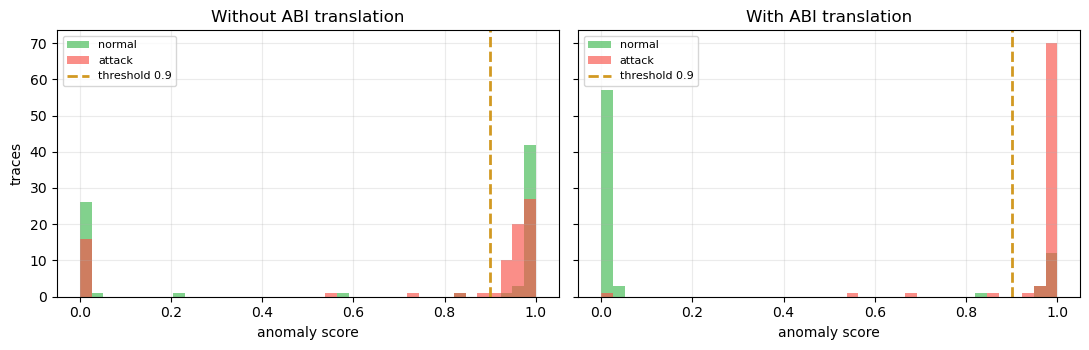

In [6]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
bins = np.linspace(0, 1, 40)
for ax, (n, a, title) in zip(axes, [
        (n_off, a_off, "Without ABI translation"),
        (norm,  atk,   "With ABI translation")]):
    ax.hist(n, bins=bins, alpha=.65, label="normal", color="#3fb950")
    ax.hist(a, bins=bins, alpha=.65, label="attack", color="#f85149")
    ax.axvline(0.9, color="#d29922", ls="--", lw=2, label="threshold 0.9")
    ax.set_title(title); ax.set_xlabel("anomaly score")
    ax.legend(fontsize=8); ax.grid(alpha=.25)
axes[0].set_ylabel("traces")
plt.tight_layout(); plt.show()

Untranslated, the two distributions overlap in the middle — the model is
guessing. Translated, normal collapses toward 0 and attack piles up near 1.

## 4 · How many syscalls before we can trust a score?

Live processes are not whole traces. `ps` or `cat` may run 20 syscalls and exit.
Scoring a short buffer means scoring mostly padding — so how short is too short?

In [7]:
rows = []
for n in [15, 30, 50, 75, 100]:
    nn = replay(f"{ADFA_ROOT}/Training_Data_Master/*.txt", n, pid_base=10000+n*100)
    aa = replay(f"{ADFA_ROOT}/Attack_Data_Master/*/*.txt", n, pid_base=20000+n*100)
    if len(nn) and len(aa):
        rows.append((n, nn.mean(), aa.mean(),
                     100*(nn >= 0.9).mean(), 100*(aa >= 0.9).mean()))

print(f"{'syscalls':>9}{'normal':>9}{'attack':>9}{'false alarms':>14}{'detection':>11}")
print("-" * 54)
for n, nm, am, fp, dr in rows:
    flag = "  <- unusable" if fp > 45 else ("  <- alert grade" if n >= 100 else "")
    print(f"{n:>9}{nm:>9.3f}{am:>9.3f}{fp:>13.0f}%{dr:>10.0f}%{flag}")

 syscalls   normal   attack  false alarms  detection
------------------------------------------------------
       15    0.975    0.997           92%       100%  <- unusable
       30    0.816    0.992           71%        98%  <- unusable
       50    0.602    0.991           54%        98%  <- unusable
       75    0.264    0.977           21%        98%
      100    0.209    0.969           20%        95%  <- alert grade


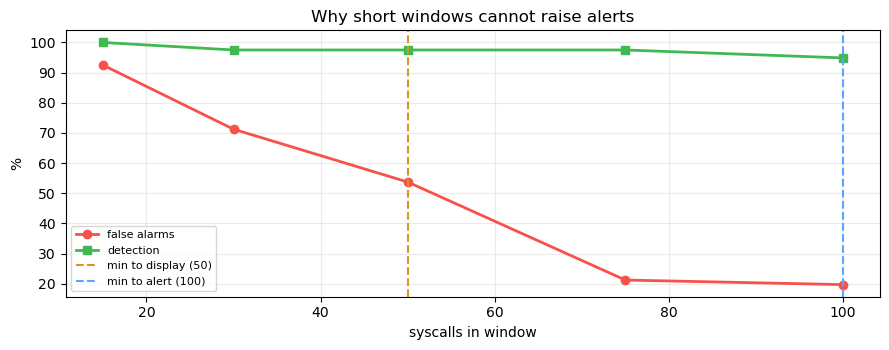

In [8]:
r = np.array(rows)
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(r[:,0], r[:,3], "o-", color="#f85149", lw=2, label="false alarms")
ax.plot(r[:,0], r[:,4], "s-", color="#3fb950", lw=2, label="detection")
ax.axvline(50,  color="#d29922", ls="--", label="min to display (50)")
ax.axvline(100, color="#58a6ff", ls="--", label="min to alert (100)")
ax.set_xlabel("syscalls in window"); ax.set_ylabel("%")
ax.set_title("Why short windows cannot raise alerts")
ax.legend(fontsize=8); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

### The rule this produces

False alarms fall steeply with window size while detection barely moves. A
15-syscall buffer is ~78 % padding, and the model reads heavy padding as
anomalous — so a short window is not a weak signal, it is a *misleading* one.

`dashboard.py` therefore separates the two uses:

| Buffer | Behaviour |
|---|---|
| < 50 | show nothing — UI prints `—` |
| 50–99 | show the score, greyed; **never alert** |
| 100 | full window — may raise an ALERT |

## 5 · Threshold

With the window fixed at 100, pick the cut-off.

In [9]:
full_n = replay(f"{ADFA_ROOT}/Training_Data_Master/*.txt", 100, pid_base=30000)
full_a = replay(f"{ADFA_ROOT}/Attack_Data_Master/*/*.txt", 100, pid_base=40000)

print(f"{'threshold':>10}{'false alarms':>14}{'detection':>11}")
print("-" * 36)
for t in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    fp, dr = 100*(full_n >= t).mean(), 100*(full_a >= t).mean()
    mark = "   <- chosen" if t == 0.9 else ""
    print(f"{t:>10.2f}{fp:>13.0f}%{dr:>10.0f}%{mark}")

print(f"\nlive setting: {p.ALERT_SCORE}")

 threshold  false alarms  detection
------------------------------------
      0.50           21%        99%
      0.60           21%        97%
      0.70           21%        96%
      0.80           21%        96%
      0.90           20%        95%   <- chosen
      0.95           20%        94%

live setting: 0.9


Raising 0.5 → 0.9 costs almost no detection and removes the shakiest alerts.
The cost of being wrong is asymmetric: a missed attack is bad, but an alert
stream nobody trusts is worse — it gets ignored, and then every attack is missed.

## 6 · Simulate a live process

Exactly what happens when eBPF streams syscalls.

In [10]:
import random
random.seed(7)

def stream(pid, pattern, n, label):
    p.buffers.pop(pid, None); p.scores.pop(pid, None)
    print(f"\n{label}  (PID {pid})")
    for i in range(1, n + 1):
        r = p.add_syscall(pid, random.choice(pattern))
        if i in (15, 50, 100):
            shown = p.get_score(pid)
            if shown is None:
                part = p.partial_score(pid)
                shown = part["score"] if part else None
            if shown is None:
                print(f"  after {i:>3} syscalls  ->  UI shows '—'  (below 50, too few)")
            else:
                tag = "ALERT" if (r and r['is_anomaly']) else "no alert"
                kind = "full window" if i >= 100 else "partial, display only"
                print(f"  after {i:>3} syscalls  ->  score {shown:.3f}   {kind:<22}{tag}")

# ordinary program: open/read/close/mmap  (x86-64 numbers, as eBPF sends them)
stream(1001, [257, 0, 3, 9, 1, 5], 100, "benign process")

# exfiltration-like: openat-heavy sweep with sends
stream(1002, [257, 0, 257, 0, 257, 44, 1], 100, "file-sweep process")


benign process  (PID 1001)
  after  15 syscalls  ->  UI shows '—'  (below 50, too few)
  after  50 syscalls  ->  score 0.998   partial, display only no alert
  after 100 syscalls  ->  score 0.982   full window           ALERT

file-sweep process  (PID 1002)
  after  15 syscalls  ->  UI shows '—'  (below 50, too few)
  after  50 syscalls  ->  score 0.964   partial, display only no alert
  after 100 syscalls  ->  score 0.001   full window           no alert


---
## Constants derived here

| Constant | Value | Set in |
|---|---|---|
| ABI translation | 376 entries | `ml/syscall_map.json` |
| Alert threshold | 0.9 | `ml/saved_model/lstm_config.json` |
| Min to display | 50 syscalls | `LivePredictor.MIN_DISPLAY_SYSCALLS` |
| Min to alert | 100 syscalls | `LivePredictor.WINDOW_SIZE` |

Change any of them and re-run this notebook — the tables and plots above are
the justification.

## Run the live system

```bash
cd ~/Downloads/Project
bash run.sh          # then open http://localhost:5000
```

Expected on startup:

```
[ML] LSTM loaded on cuda | AUC=0.9854
[ML] Syscall ABI map loaded: 376 x86_64 -> i686 translations
[ML] LSTM model loaded — real-time anomaly scoring enabled
```

To generate suspicious activity, in a second terminal:

```bash
venv/bin/python3 src/simulate_thief.py snoop
```